#Wikipedia NLP Clustering

##Problem Definition

The goal of this project is to use Natural Language Processing (NLP) to identify the ten most similar people based on their biographies. After cleaning and preprocessing the text, TF-IDF is used to convert biographies into numerical features, and K-Nearest Neighbors (KNN) is used to measure similarity between individuals. Sentiment analysis is performed on the reference person’s biography, and similarity rankings from DBpedia summaries are compared with rankings from full Wikipedia articles. Finally, an interactive notebook allows users to select a person and view their ten closest matches.

##Data Collection

In [1]:
%%capture install_output
%%bash

#Install necessary NLP and Wikipedia API libraries
pip install -q -U textblob wikipedia-api
#Download TextBlob for NLP tasks
python -m textblob.download_corpora

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import wikipediaapi
import ipywidgets as widgets #Used to create dropdown and button
import urllib.parse #Used to decode special (foreign) characters

from textblob import TextBlob #Tokenization, Counting words, Parts of Speech Sentiment Analysis
from sklearn.feature_extraction.text import CountVectorizer #Understand Bag of Words
from sklearn.feature_extraction.text import TfidfVectorizer #Final Representation
from sklearn.neighbors import NearestNeighbors #Primary algorithm
from IPython.display import display #Pushes widgets to screen

from google.colab import userdata
import os

from ipywidgets import interact

#Load Data from Hugging Face

In [3]:
hf_url = 'https://huggingface.co/datasets/stephanie465337/Data_Science-21/resolve/main/wiki.parquet'
hf_url

'https://huggingface.co/datasets/stephanie465337/Data_Science-21/resolve/main/wiki.parquet'

In [4]:
df_clean = pd.read_parquet(hf_url)
df_clean.shape

(42786, 2)

#NLP Preprocessing

##Part 1 - Reference Person

In [ ]:
#Randomly select a person
# df_clean['clean_name'].sample(1)

In [6]:
#Enter reference person
reference_person = 'Neville Harper'

#Verify person exists
person = df_clean[df_clean['clean_name'] == reference_person]

if person.empty:
  print('Person not found.')
else:
  reference_text = person['clean_text'].iloc[0] #First row returned

  print('Reference Person:')
  print(reference_person)

Reference Person:
Neville Harper


###Sentiment

In [7]:
#Create TextBlob
blob = TextBlob(reference_text)

#Display sentences
print('Sentences:')
for sentence in blob.sentences:
  print(sentence)

Sentences:
neville john nev harper born 10 september 1926 is a former australian politicianhe wa born in brisbane to neville barclay harper and hazel jean ne gardner he attended new farm and nundah state school and then brisbane grammar school 194044 before becoming a grazier farmer and real estate valuer on 12 november 1949 he married marjorie pointon with whom he had two daughter from 1945 to 1947 he served in the royal australian navy a a sublieutenant aboard hmas hawkesbury before returning to manage cattle property in barmundu and kingaroy in 1952 he wa appointed manager of mactaggarts station in cunnamullaharper wa a member of the national party and served a chairman of the wandoan branch he served a chairman of the electorate council for the state seat of rom 196972 and auburn 197280 and president of the council for the federal seat of maranoa 197277 for which he also directed the 1974 and 1975 campaign in 1976 he wa elected to taroom shire council and he wa also elected vicepre

###TF-IDF Text Representation
Gives more importance to meaningful words

In [8]:
#Convert words into numbers
#Remove stop words (words that do not add meaning)
tfidf = TfidfVectorizer(
    stop_words="english",
    # min_df=2, #Ignores words that appear once
    # max_df=0.8, #Ignores words appearing in >80% of biographies
    # ngram_range=(1,2) #Captures phrases
)

tfidf_matrix = tfidf.fit_transform(df_clean['clean_text'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (42786, 423641)


###Similarity Search (KNN)

In [9]:
#Create KNN similarity model
knn = NearestNeighbors(
    n_neighbors=11,
    #Asks 'Do these biographies point in the same direction?'
    metric='cosine' #Ignores size and focuses on pattern of words
)

knn.fit(tfidf_matrix)


#Find index of reference person
reference_index = df_clean.index[
    df_clean['clean_name'] == reference_person
][0]


#Find closest biographies
distances, indices = knn.kneighbors(
    tfidf_matrix[reference_index]
)


#Display top 10 similar people
similar_people = pd.DataFrame({
    'Name': df_clean.iloc[indices[0][1:]]['clean_name'].values,
    'Similarity Distance': distances[0][1:] #Lower distance = closer
})

similar_people

,Name,Similarity Distance
0,Stuart Copeland,0.781568
1,Geoff Muntz,0.790501
2,Dennis Young (Australian politician),0.790538
3,Arch Bevis,0.790713
4,Mark Lewis (politician),0.791832
5,Vaughan Johnson (politician),0.794224
6,Tom Webster (politician),0.797250
7,Jon Sullivan,0.798742
8,Brian Austin,0.799027
9,David Hamill,0.802170


In [10]:
# Install the library (if not already installed)
!pip install -q dataframe_image

import dataframe_image as dfi

# Filter the DataFrame to only keep 'Name' and 'Similarity Score'
similar_people_filtered = similar_people[['Name', 'Similarity Distance']]

# Hide the numeric index using pandas styler
styled_table = similar_people_filtered.style.hide(axis="index")

# Export the styled dataframe directly to a PNG image
dfi.export(styled_table, 'similar_people_table_styled.png', table_conversion='matplotlib')

###Sentiment Analysis

In [11]:
#Extract sentiment scores
sentiment = blob.sentiment


print("Reference Person:", reference_person)
print("Polarity Score:", sentiment.polarity) #Emotional direction, 0=neutral
print("Subjectivity Score:", sentiment.subjectivity) # 0=factual, 1=opinion


#Convert polarity into sentiment label
if sentiment.polarity > 0:
    label = 'Positive'
elif sentiment.polarity < 0:
    label = 'Negative'
else:
    label = 'Neutral'


print("Sentiment:", label)

Reference Person: Neville Harper
Polarity Score: 0.08474025974025975
Subjectivity Score: 0.28603896103896104
Sentiment: Positive


###Convert Distance to Similarity

In [12]:
similar_people['Similarity Score'] = 1 - similar_people['Similarity Distance']
similar_people.sort_values(
    'Similarity Score',
    ascending=False
)

,Name,Similarity Distance,Similarity Score
0,Stuart Copeland,0.781568,0.218432
1,Geoff Muntz,0.790501,0.209499
2,Dennis Young (Australian politician),0.790538,0.209462
3,Arch Bevis,0.790713,0.209287
4,Mark Lewis (politician),0.791832,0.208168
5,Vaughan Johnson (politician),0.794224,0.205776
6,Tom Webster (politician),0.797250,0.202750
7,Jon Sullivan,0.798742,0.201258
8,Brian Austin,0.799027,0.200973
9,David Hamill,0.802170,0.197830


###Visualization

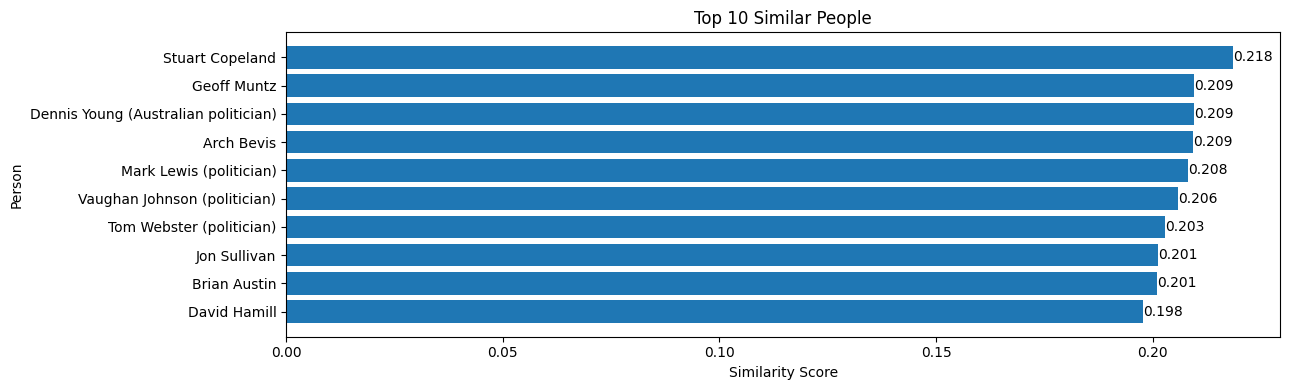

In [13]:
plt.figure(figsize=(13,4))

bars = plt.barh(
    similar_people['Name'],
    similar_people['Similarity Score']
)

plt.xlabel("Similarity Score")
plt.ylabel("Person")
plt.title(
    "Top 10 Similar People"
)

plt.gca().invert_yaxis()

# Add score labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va='center'
    )

plt.tight_layout()

plt.savefig(
    "top_10_similar_people.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Part 2 - Wikipedia

In [14]:
#Connect to Wikipedia
wiki = wikipediaapi.Wikipedia(
    user_agent='NLP_Project/1.0', #Identifies program
    language='en'
)

###Retrieve Wikipedia Page for Reference Person

In [15]:
#Get Wikipedia page for reference person
reference_page = wiki.page(reference_person)


if reference_page.exists():
    print("Wikipedia page found.")
else:
    print("Wikipedia page not found.")


#Store Wikipedia text
reference_wiki = reference_page.text


#Preview article
print(reference_wiki[:1000])

Wikipedia page found.
Neville John Harper (10 September 1926 – 29 September 2023) was an Australian politician.

Life and career
Neville John Harper was born in Brisbane on 10 September 1926, to Neville Barclay Harper and Hazel Jane, née Gardner. He attended New Farm and Nundah State Schools and then Brisbane Grammar School (1940–44) before becoming a grazier, farmer and real estate valuer. On 12 November 1949, he married Marjorie Pointon, with whom he had two daughters. From 1945 to 1947 he served in the Royal Australian Navy as a sub-lieutenant aboard HMAS Hawkesbury before returning to manage cattle properties in Barmundu and Kingaroy. In 1952 he was appointed manager of Mactaggarts station in Cunnamulla.
Harper was a member of the National Party, and served as chairman of the Wandoan branch. He served as chairman of the electorate councils for the state seats of Roma (1969–72) and Auburn (1972–80) and president of the council for the federal seat of Maranoa (1972–77), for which he 

###Sentiment Analysis of Wikipedia Article

In [16]:
#Create TextBlob
wiki_blob = TextBlob(reference_wiki)


#Extract sentiment
wiki_sentiment = wiki_blob.sentiment

print('Reference Person:', reference_person)
print('Wikipedia Polarity:', wiki_blob.sentiment.polarity)
print('Wikipedia Subjectivity:', wiki_blob.sentiment.subjectivity)

Reference Person: Neville Harper
Wikipedia Polarity: 0.09125874125874127
Wikipedia Subjectivity: 0.30804195804195805


###Collect Wikipedia Pages for Top 10 Similar People

In [27]:
#Store Wikipedia articles
wiki_text = []

#Look through Part 1 results
for name in similar_people['Name']:

    #Retreive each article
    person_page = wiki.page(name)

    if person_page.exists():
        wiki_text.append({
            "Name": name,
            "Wikipedia_Text": person_page.text
        })
    else:
        print(f"No Wikipedia page found for {name}")


#Create dataframe
wiki_df = pd.DataFrame(wiki_text)
wiki_df.head(10)

,Name,Wikipedia_Text
0,Stuart Copeland,Stuart William Copeland (born 19 January 1968)...
1,Geoff Muntz,Geoffrey Hugh Muntz (11 July 1938 – 8 August 2...
2,Dennis Young (Australian politician),Dr Dennis Charles Young (born 7 August 1947) ...
3,Arch Bevis,Archibald Ronald Bevis (born 10 April 1955) is...
4,Mark Lewis (politician),Mark William Lewis (born 27 November 1957) is ...
5,Vaughan Johnson (politician),Vaughan Gregory Johnson (20 July 1947 – 22 Ja...
6,Tom Webster (politician),Thomas Stephen Webster (born 5 July 1950) is a...
7,Jon Sullivan,Jonathan Harold Sullivan (10 November 1950 – 1...
8,Brian Austin,Brian Douglas Austin (born 22 March 1943) is a...
9,David Hamill,David John Hamill (born 18 September 1957) is...


###Combine Reference Person + Similar People

In [29]:
#Create dataframe
comparison_df = pd.concat(
    [
        pd.DataFrame({
            "Name": [reference_person],
            "Text": [reference_wiki]
        }),

        #Matches columns
        wiki_df.rename(
            columns={"Wikipedia_Text":"Text"}
        )
    ],

    #Creates new row numbers
    ignore_index=True
)


comparison_df.head(10)

,Name,Text
0,Neville Harper,Neville John Harper (10 September 1926 – 29 Se...
1,Stuart Copeland,Stuart William Copeland (born 19 January 1968)...
2,Geoff Muntz,Geoffrey Hugh Muntz (11 July 1938 – 8 August 2...
3,Dennis Young (Australian politician),Dr Dennis Charles Young (born 7 August 1947) ...
4,Arch Bevis,Archibald Ronald Bevis (born 10 April 1955) is...
5,Mark Lewis (politician),Mark William Lewis (born 27 November 1957) is ...
6,Vaughan Johnson (politician),Vaughan Gregory Johnson (20 July 1947 – 22 Ja...
7,Tom Webster (politician),Thomas Stephen Webster (born 5 July 1950) is a...
8,Jon Sullivan,Jonathan Harold Sullivan (10 November 1950 – 1...
9,Brian Austin,Brian Douglas Austin (born 22 March 1943) is a...


###Convert Wikipedia Pages into TF-IDF Vectors

In [30]:
#Create TF-IDF model
wiki_tfidf = TfidfVectorizer(
    stop_words='english',
    # min_df=2, #Ignores words that appear once
    # max_df=0.8, #Ignores words appearing in >80% of biographies
    # ngram_range=(1,2) #Captures phrases
)

#Creates numerical feature matrix
wiki_matrix = wiki_tfidf.fit_transform(
    comparison_df['Text']
)

print("Wikipedia TF-IDF Shape:", wiki_matrix.shape)

Wikipedia TF-IDF Shape: (11, 1025)


###Find Wikipedia Similarity Ranking

In [31]:
#Create KNN model
wiki_knn = NearestNeighbors(
    n_neighbors=11,
    metric='cosine'
)

wiki_knn.fit(wiki_matrix)

#Find closest Wikipedia articles
wiki_distances, wiki_indices = wiki_knn.kneighbors(
    wiki_matrix[0]
)

#Create ranking dataframe
wiki_results = pd.DataFrame({
    'Wikipedia Rank': range(1, 11),
    'Name': comparison_df.iloc[wiki_indices[0][1:]]['Name'].values,
    'Wikipedia Distance': wiki_distances[0][1:]
})

#Convert distance to similarity
wiki_results['Wikipedia Similarity'] = (
    1 - wiki_results['Wikipedia Distance']
)

wiki_results

,Wikipedia Rank,Name,Wikipedia Distance,Wikipedia Similarity
0,1,Geoff Muntz,0.855252,0.144748
1,2,Tom Webster (politician),0.859636,0.140364
2,3,Brian Austin,0.862669,0.137331
3,4,Arch Bevis,0.863320,0.136680
4,5,David Hamill,0.864701,0.135299
5,6,Stuart Copeland,0.868593,0.131407
6,7,Dennis Young (Australian politician),0.876935,0.123065
7,8,Vaughan Johnson (politician),0.878108,0.121892
8,9,Jon Sullivan,0.888318,0.111682
9,10,Mark Lewis (politician),0.916007,0.083993


###Compare Part 1 vs Wikipedia Ranking

In [32]:
#Part 1 Ranking
part1_ranks = similar_people[['Name']].copy()

part1_ranks['TF-IDF Rank'] = range(
    1,
    len(part1_ranks) + 1
)

#Merge rankings
comparison = part1_ranks.merge(
    wiki_results[
        [
            'Name',
            'Wikipedia Rank',
            'Wikipedia Similarity'
        ]
    ],
    on='Name'
)

comparison

,Name,TF-IDF Rank,Wikipedia Rank,Wikipedia Similarity
0,Stuart Copeland,1,6,0.131407
1,Geoff Muntz,2,1,0.144748
2,Dennis Young (Australian politician),3,7,0.123065
3,Arch Bevis,4,4,0.136680
4,Mark Lewis (politician),5,10,0.083993
5,Vaughan Johnson (politician),6,8,0.121892
6,Tom Webster (politician),7,2,0.140364
7,Jon Sullivan,8,9,0.111682
8,Brian Austin,9,3,0.137331
9,David Hamill,10,5,0.135299


###Calculate Rank Difference

In [33]:
comparison['Rank Difference'] = (
    comparison['TF-IDF Rank']
    -
    comparison['Wikipedia Rank']
).abs()

comparison

,Name,TF-IDF Rank,Wikipedia Rank,Wikipedia Similarity,Rank Difference
0,Stuart Copeland,1,6,0.131407,5
1,Geoff Muntz,2,1,0.144748,1
2,Dennis Young (Australian politician),3,7,0.123065,4
3,Arch Bevis,4,4,0.136680,0
4,Mark Lewis (politician),5,10,0.083993,5
5,Vaughan Johnson (politician),6,8,0.121892,2
6,Tom Webster (politician),7,2,0.140364,5
7,Jon Sullivan,8,9,0.111682,1
8,Brian Austin,9,3,0.137331,6
9,David Hamill,10,5,0.135299,5


###Model Evaluation Metric

In [34]:
average_rank_differnce = comparison['Rank Difference'].mean()

print(f"Average Rank Difference: {average_rank_differnce:.2f}") # 2 decimal places
#On average, people moved 3.4 positions between biography and Wikipedia rankings

Average Rank Difference: 3.40


###Visualization

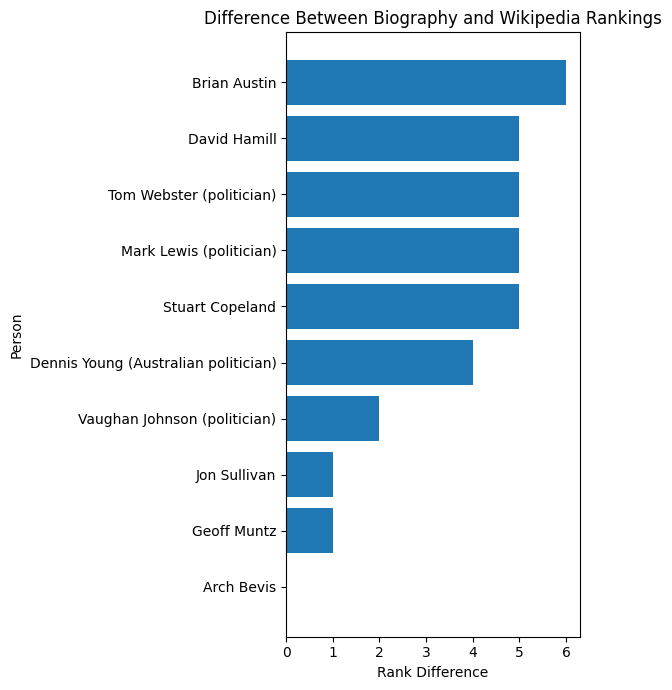

In [40]:
#Sort the dataframe by 'Rank Difference'
#Sort comparison
comparison_sorted = comparison.sort_values('Rank Difference', ascending=True)

plt.figure(figsize=(6, 7))

#Plot using barh for a horizontal bar chart
plt.barh(comparison_sorted['Name'], comparison_sorted['Rank Difference'])

plt.xlabel('Rank Difference')
plt.ylabel('Person')
plt.title('Difference Between Biography and Wikipedia Rankings')
plt.tight_layout()

#Save graphic
plt.savefig('rank_difference_chart.png', dpi=300, bbox_inches='tight')

plt.show()

##Part 3 - Interactive Notebook

In [41]:
#Create function
def find_similar_people(person_name):

  #Check if the person exists
  if person_name not in df_clean['clean_name'].values:
    print(f"'{person_name}' was not found in the dataset.")
    return

  #Find the reference person's index
  reference_index = df_clean[df_clean['clean_name'] == person_name].index[0]

  #Find 10 nearest neighbors
  distances, indices = knn.kneighbors(tfidf_matrix[reference_index])

  #Get biography of reference person's
  reference_text = df_clean.loc[df_clean['clean_name'] == person_name, 'clean_text'].iloc[0]

  #Sentiment Analysis
  blob = TextBlob(reference_text)

  #Create results DataFrame
  results = pd.DataFrame({
      'Name': df_clean.iloc[indices[0][1:]]['clean_name'].values,
      'Distance': distances[0][1:]
  })

  #Convert distance to similarity score
  results['Similarity Score'] = (1 - results['Distance'])

  #Display results
  print('=' * 60)
  print(f"Reference Person: {person_name}")
  print('=' * 60)

  print(f'Polarity: {blob.sentiment.polarity:.3f}')
  print(f'Subjectivity: {blob.sentiment.subjectivity:.3f}')
  print()

  print('10 Closest Individuals')

  display(results.sort_values('Similarity Score', ascending=False))

#Create searchable text box
person_input = widgets.Combobox(
    placeholder="Type a person's name: ",
    options=sorted(df_clean['clean_name'].unique()),
    description='Person:',
    ensure_option=False,
    layout=widgets.Layout(width='450px')
)

#Create button
button = widgets.Button(
    description='Find Similar People',
    button_style='success'
)

#Button action
def on_button_clicked(b):
  find_similar_people(person_input.value)

button.on_click(on_button_clicked)

#Display widgets
display(person_input)
display(button)

Combobox(value='', description='Person:', layout=Layout(width='450px'), options=(' Renate Lorenz', "'Ilima Lei…

Button(button_style='success', description='Find Similar People', style=ButtonStyle())

Reference Person: Leonardo DiCaprio
Polarity: 0.185
Subjectivity: 0.278

10 Closest Individuals


,Name,Distance,Similarity Score
0,Jeremy Irons,0.630366,0.369634
1,Amanda Seyfried,0.639559,0.360441
2,Jack Nicholson,0.650962,0.349038
3,Nicole Kidman,0.660349,0.339651
4,Robert De Niro,0.678968,0.321032
5,Mark Wahlberg,0.685977,0.314023
6,George Clooney,0.686520,0.313480
7,Ethan Hawke,0.700799,0.299201
8,Clint Eastwood,0.710180,0.289820
9,Amy Adams,0.719353,0.280647
